# Online Shoppers Revenue Prediction - Decision Tree Pipeline

## Project Overview
This project builds a **Decision Tree Classification model** to predict whether an online shopping session will result in revenue (purchase) or not. We use a complete ML pipeline with preprocessing and hyperparameter tuning.

---

## Step 1: Import Required Libraries
- **pandas & numpy**: Data manipulation and numerical operations
- **train_test_split**: Split data into training (80%) and testing (20%) sets
- **ColumnTransformer**: Apply different preprocessing to different feature types
- **StandardScaler**: Normalize numerical features to have mean=0, std=1
- **OneHotEncoder**: Convert categorical variables into binary columns
- **Pipeline**: Chain preprocessing and model steps together
- **DecisionTreeClassifier**: The main model for classification
- **Metrics**: F1-score, classification report, and confusion matrix for evaluation

---

## Step 2: Load Data & Separate Features and Target
- Read the CSV file into a pandas DataFrame
- **X (features)**: All columns except "Revenue" - used to make predictions
- **y (target)**: The "Revenue" column - what we're trying to predict (0 or 1)

---

## Step 3: Identify Feature Types
- **Numerical features**: Columns with int64 or float64 data types (e.g., ProductRelated, BounceRate)
- **Categorical features**: Columns with object or category data types (e.g., Month, VisitorType)
This separation is important because different features need different preprocessing.

---

## Step 4: Train-Test Split
- Split data into 80% training and 20% testing
- **test_size=0.2**: Use 20% of data for testing
- **random_state=42**: Ensures reproducibility (same split every time)
- **stratify=y**: Maintains the same class ratio in both train and test sets (important for imbalanced data)

---

## Step 5: Build Preprocessing Pipeline
Create a ColumnTransformer that handles both feature types:
- **Numerical features**: Apply StandardScaler to normalize values
- **Categorical features**: Apply OneHotEncoder to convert categories into binary columns

---

## Step 6: Configure Decision Tree Model
Key hyperparameters to prevent overfitting:
- **max_depth=6**: Limit tree depth to 6 levels (prevents memorizing the data)
- **min_samples_leaf=30**: Each leaf node must have at least 30 samples (prevents creating rules for just a few examples)
- **class_weight="balanced"**: Handles class imbalance by giving more weight to minority class
- **random_state=42**: Ensures reproducibility

---

## Step 7: Create Complete Pipeline
Combine preprocessing and model into one Pipeline object:
- First step: Preprocess data (scale/encode features)
- Second step: Train Decision Tree model
This ensures preprocessing is applied consistently to train and test data

---

## Step 8: Train the Model
Fit the pipeline on training data. The pipeline automatically:
1. Preprocesses training data
2. Trains the decision tree on preprocessed data

---

## Step 9: Evaluate Model Performance
Make predictions on test data and evaluate using:
- **F1-score**: Balance between precision and recall (good for imbalanced datasets)
- **Classification Report**: Shows precision, recall, and F1 for each class
- **Confusion Matrix**: Shows true positives, false positives, true negatives, and false negatives

---

## Step 10: Hyperparameter Tuning with GridSearchCV
Test multiple combinations of hyperparameters:
- Test max_depth: [4, 6, 8]
- Test min_samples_leaf: [20, 30, 50]
- Use 5-fold cross-validation to evaluate each combination
- Select the combination with the best F1-score
- **n_jobs=-1**: Uses all CPU cores to speed up the process

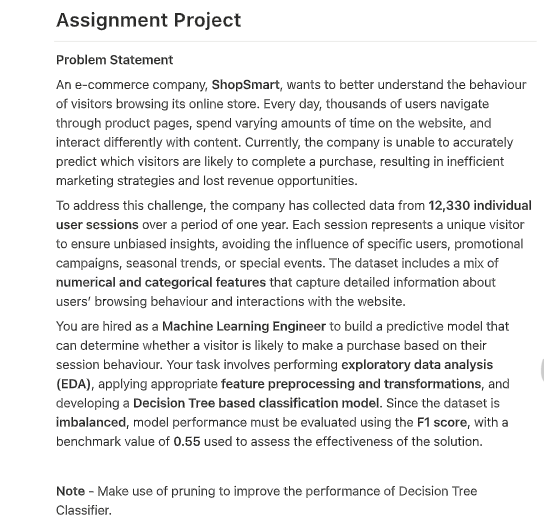

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("online_shoppers.csv")

X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

In [6]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# Preprocessng Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [11]:
dt = DecisionTreeClassifier(
    max_depth=6,              # prevents deep overfitting
    min_samples_leaf=30,      # smooths decision boundaries
    class_weight="balanced",  # handles imbalance
    random_state=42
)

In [12]:
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", dt)
    ]
)

In [13]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=30,
                                        random_state=42))])

In [14]:
y_pred = pipe.predict(X_test)

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6278381046396841

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      2084
           1       0.50      0.83      0.63       382

    accuracy                           0.85      2466
   macro avg       0.73      0.84      0.77      2466
weighted avg       0.89      0.85      0.86      2466


Confusion Matrix:
 [[1771  313]
 [  64  318]]


# Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [20, 30, 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best F1: 0.6343735129725652
Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 50}
